# 05 — Baseline de modelado

Baseline para predecir `rhythm_label` a partir de las features generadas en `04_windowing_and_feature_engineering.ipynb`.

**Alcance de este notebook**

- Validar mecánica del pipeline: `SimpleImputer → StandardScaler → Clasificador`.
- Split estricto por `case_id` (`GroupKFold` / `GroupShuffleSplit`).
- Manejo de desbalance vía `class_weight="balanced"`.
- Reportar métricas macro, reporte por clase con soporte y matriz de confusión en conteos absolutos con totales por fila y columna.

**Restricciones obligatorias**

- `beat_type` **NO** se usa como predictor (lo verifica `assert_no_forbidden_features`).
- Split por `case_id`, nunca por ventana ni latido aleatorio.
- No reportar cifras antes de ejecutar las celdas con datos reales.

**Pre-requisito**

Haber ejecutado:
1. `03_ecg_loading_and_visualization.ipynb` para descargar los ECG de todos los `case_id` que se quieran usar.
2. `04_windowing_and_feature_engineering.ipynb` para generar `data/processed/features_baseline.parquet` con esos casos.

## 1. Setup

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.modeling import (
    assert_no_forbidden_features,
    build_logreg_pipeline,
    build_rf_pipeline,
    make_group_kfold,
    make_group_split,
    safe_n_splits,
)
from src.evaluation import (
    class_support_per_split,
    classes_missing_in_train,
    compute_macro_metrics,
    confusion_matrix_with_totals,
    per_class_report,
)
from src.utils import get_logger, set_seed

set_seed(config.RANDOM_SEED)
logger = get_logger("nb05")
sns.set_theme(context="notebook", style="whitegrid")

## 2. Carga de la tabla de features

In [14]:
features_path = config.PROCESSED_DIR / "features_baseline.parquet"
if not features_path.exists():
    raise FileNotFoundError(
        f"No existe {features_path}. Ejecuta primero 04_windowing_and_feature_engineering.ipynb."
    )

df = pd.read_parquet(features_path)

n_before = len(df)

# 1) Eliminar filas con label NaN.
df = df.dropna(subset=[config.TARGET_COLUMN])

# 2) Defensivo: parquets generados con versiones anteriores podían guardar la
#    etiqueta como la cadena literal "nan"/"NaN" en lugar de un NaN real.
mask_string_nan = df[config.TARGET_COLUMN].astype(str).str.strip().str.lower().isin({"nan", "none", ""})
df = df.loc[~mask_string_nan].copy()

n_after = len(df)
logger.info("Filas con label válido: %d / %d", n_after, n_before)

print("Shape:", df.shape)
print("Columnas:", list(df.columns))
df.head()

2026-05-19 20:41:24 | nb05 | INFO | Filas con label válido: 638690 / 638690


Shape: (638690, 39)
Columnas: ['case_id', 'window_id', 'beat_index', 'start_sample', 'end_sample', 'start_time', 'end_time', 'rhythm_label', 'original_nan_pct', 'max_nan_gap_seconds', 'was_interpolated', 'quality_status', 'quality_reason', 'mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']


,case_id,window_id,beat_index,start_sample,end_sample,start_time,end_time,rhythm_label,original_nan_pct,max_nan_gap_seconds,...,rr_next,rr_mean_local,rr_ratio,case_rr_count,case_rr_mean,case_rr_std,case_rr_min,case_rr_max,case_rr_rmssd,case_rr_pnn50
0,12,0,0,4320811,4321811,8641.622,8643.622,N,0.0,0.0,...,0.744444,0.744444,NaN,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
1,12,1,1,4321183,4322183,8642.366,8644.366,N,0.0,0.0,...,0.755556,0.750000,0.985294,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
2,12,2,2,4321561,4322561,8643.122,8645.122,N,0.0,0.0,...,0.755556,0.755556,1.000000,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
3,12,3,3,4321939,4322939,8643.878,8645.878,N,0.0,0.0,...,0.763889,0.759722,0.989091,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
4,12,4,4,4322321,4323321,8644.642,8646.642,N,0.0,0.0,...,0.766667,0.765278,0.996377,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973


## 2b. Tarea A — Auditoría de ventanas y estrategia de split

Antes de entrenar se documenta explícitamente cómo se construyeron las ventanas
y por qué el split **debe** hacerse por `case_id` (no por fila).

In [15]:
# ================================================================
# TAREA A: Auditoria de ventanas y estrategia de split
# ================================================================

FS_HZ_AUD      = config.DEFAULT_ECG_FS_HZ       # 500 Hz
WIN_SEC_AUD    = config.DEFAULT_WINDOW_SECONDS  # 2.0 s
OVERLAP_PARAM  = config.DEFAULT_WINDOW_OVERLAP  # 0.0
WIN_SAMPLES    = int(round(WIN_SEC_AUD * FS_HZ_AUD))

print("=" * 66)
print("AUDITORIA DE VENTANAS — parametros usados en notebook 04")
print("=" * 66)
print(f"  Frecuencia de muestreo        : {FS_HZ_AUD} Hz")
print(f"  Duracion de ventana           : {WIN_SEC_AUD} s = {WIN_SAMPLES} muestras")
print(f"  Parametro overlap (sintetico) : {OVERLAP_PARAM}  (sin ventanas auxiliares)")
print("  Anclaje de ventana            : centrada en cada latido anotado")
print()
print("Solapamiento NATURAL segun frecuencia cardiaca:")
print(f"  {'HR (bpm)':>9} {'Inter-latido (s)':>17} {'Overlap (s)':>13} {'Overlap (%)':>12}")
print("  " + "-" * 54)
for hr in [30, 45, 60, 75, 100, 120, 150]:
    rr      = 60.0 / hr
    ov_s    = max(0.0, WIN_SEC_AUD - rr)
    ov_pct  = 100.0 * ov_s / WIN_SEC_AUD
    note = "  <- reposo tipico" if hr in (60, 75) else ""
    print(f"  {hr:>9} {rr:>17.3f} {ov_s:>13.3f} {ov_pct:>11.1f}%{note}")
print()
print("CONCLUSION:")
print("  Las ventanas SON solapadas para HR fisiologicos normales (>30 bpm).")
print("  Con HR 60-100 bpm el solapamiento natural es del 50-67%.")
print("  Causa: ventanas centradas en latidos; latidos consecutivos son <2 s.")
print()
print("ESTRATEGIA DE SPLIT correcta:")
print("  GroupShuffleSplit / GroupKFold por case_id (ya implementado).")
print("  Todas las ventanas del mismo caso van al mismo fold.")
print("  -> NO hay leakage por solapamiento entre ventanas del mismo caso.")
print("  -> Split aleatorio por fila produciria metricas artificialmente infladas.")
print("=" * 66)
print()
print("Distribucion de ventanas por case_id:")
wpc = df.groupby(config.CASE_ID_COLUMN).size()
print(f"  min={wpc.min()}  mediana={wpc.median():.0f}  max={wpc.max()}  total={wpc.sum():,}")

AUDITORIA DE VENTANAS — parametros usados en notebook 04
  Frecuencia de muestreo        : 500 Hz
  Duracion de ventana           : 2.0 s = 1000 muestras
  Parametro overlap (sintetico) : 0.0  (sin ventanas auxiliares)
  Anclaje de ventana            : centrada en cada latido anotado

Solapamiento NATURAL segun frecuencia cardiaca:
   HR (bpm)  Inter-latido (s)   Overlap (s)  Overlap (%)
  ------------------------------------------------------
         30             2.000         0.000         0.0%
         45             1.333         0.667        33.3%
         60             1.000         1.000        50.0%  <- reposo tipico
         75             0.800         1.200        60.0%  <- reposo tipico
        100             0.600         1.400        70.0%
        120             0.500         1.500        75.0%
        150             0.400         1.600        80.0%

CONCLUSION:
  Las ventanas SON solapadas para HR fisiologicos normales (>30 bpm).
  Con HR 60-100 bpm el solapamient

## 3. Diagnóstico de clases por `case_id` (crítico antes del split)

El split se hace por `case_id`. Si una clase aparece en pocos casos (en el extremo: un único caso), entonces ese caso debe estar en train **o** en test, no en ambos. Si está en test, el modelo nunca verá esa clase en entrenamiento y su recall será 0 por construcción.

Esta celda muestra cuántos latidos por clase tiene cada caso y en cuántos casos distintos aparece cada clase. Si alguna clase aparece en **un único caso**, hay que tomar decisiones explícitas (excluirla, descargar más casos que la contengan, o asumir que su métrica será dura).

In [16]:
crosstab = (
    df.groupby([config.CASE_ID_COLUMN, config.TARGET_COLUMN])
      .size()
      .unstack(fill_value=0)
)
print("Casos únicos:", crosstab.shape[0])
print("Clases únicas:", crosstab.shape[1])
crosstab

Casos únicos: 481
Clases únicas: 10


rhythm_label,AFIB/AFL,AVB,N,Patterned Atrial Ectopy,Patterned Ventricular Ectopy,SND,SVTA,Unclassifiable,VT,WAP/MAT
case_id,,,,,,,,,,
12,0,0,983,0,123,0,0,0,0,0
13,0,0,670,0,623,0,0,0,0,0
19,0,0,1645,0,0,0,6,0,0,0
42,0,0,1146,0,16,0,0,0,0,0
96,0,0,1554,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
6344,0,0,752,19,0,0,0,0,0,0
6354,0,0,200,0,239,0,0,0,1,0
6355,1152,0,0,0,0,0,0,0,0,0


In [17]:
cases_per_class = (crosstab > 0).sum(axis=0).rename("cases_with_class").sort_values()
totals_per_class = crosstab.sum(axis=0).rename("total_windows").reindex(cases_per_class.index)
summary = pd.concat([totals_per_class, cases_per_class], axis=1)
summary

,total_windows,cases_with_class
rhythm_label,,
Unclassifiable,59,5
AVB,4193,10
WAP/MAT,10047,25
SND,22224,66
Patterned Atrial Ectopy,19946,85
VT,1573,87
SVTA,6396,108
Patterned Ventricular Ectopy,23902,109
AFIB/AFL,158473,111


In [18]:
singleton_classes = cases_per_class[cases_per_class <= 1].index.tolist()
if singleton_classes:
    print(
        "AVISO: las siguientes clases aparecen en <=1 case_id.\n"
        "Con split por case_id su recall puede ser 0 cuando ese caso queda en test.\n",
        singleton_classes,
    )
else:
    print("Todas las clases aparecen en al menos 2 case_id.")

Todas las clases aparecen en al menos 2 case_id.


## 4. Preparación de X, y, groups

Se excluyen como features: `case_id`, `rhythm_label`, `beat_type`, `bad_signal_quality`, e identificadores de ventana (`beat_index`, `start_sample`, `end_sample`).

In [19]:
# Columnas que nunca pueden ser features (metadatos, target, diagnóstico de calidad)
non_feature_cols = set(config.FORBIDDEN_FEATURE_COLUMNS) | {
    "beat_index",
    "start_sample",
    "end_sample",
    "window_id",
    "start_time",
    "end_time",
    "quality_status",
    "quality_reason",
    "original_nan_pct",
    "max_nan_gap_seconds",
    "was_interpolated",
}

# Columnas del dataframe que pertenecen al conjunto no-feature
excluded_meta = [c for c in df.columns if c in non_feature_cols]

# Candidatas: todo lo que no es no-feature
candidate_cols = [c for c in df.columns if c not in non_feature_cols]

# Excluir además cualquier candidata no numérica (strings residuales, booleans object, etc.)
non_numeric_cols = (
    df[candidate_cols]
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)
feature_cols = (
    df[candidate_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# Bloqueos metodológicos
assert_no_forbidden_features(feature_cols)
assert config.TARGET_COLUMN not in feature_cols, f"{config.TARGET_COLUMN} no debe ser feature"
assert config.CASE_ID_COLUMN not in feature_cols, f"{config.CASE_ID_COLUMN} no debe ser feature"
assert "beat_type" not in feature_cols, "beat_type no debe ser feature"
assert len(feature_cols) > 0, "No quedaron columnas numéricas para entrenar"

# X con dtype float explícito para evitar TypeError en np.isnan
X = df[feature_cols].to_numpy(dtype=float)
y = df[config.TARGET_COLUMN].to_numpy()
groups = df[config.CASE_ID_COLUMN].to_numpy()

print("Excluidas (metadatos/diagnóstico):", excluded_meta)
print("Excluidas (no numéricas)         :", non_numeric_cols)
print(f"Features usadas ({len(feature_cols)}):", feature_cols)
print("X shape:", X.shape, "| y shape:", y.shape,
      "| grupos únicos:", np.unique(groups).shape[0])
print("NaN en X:", int(np.isnan(X).sum()), " (imputados por el Pipeline)")

Excluidas (metadatos/diagnóstico): ['case_id', 'window_id', 'beat_index', 'start_sample', 'end_sample', 'start_time', 'end_time', 'rhythm_label', 'original_nan_pct', 'max_nan_gap_seconds', 'was_interpolated', 'quality_status', 'quality_reason']
Excluidas (no numéricas)         : []
Features usadas (26): ['mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']
X shape: (638690, 26) | y shape: (638690,) | grupos únicos: 481
NaN en X: 1920  (imputados por el Pipeline)


## 4b. Tarea B — Correlación entre features

Detecta redundancias antes de entrenar. Las features de la misma familia
(p.ej. `std`/`var`) pueden tener correlación perfecta, lo que perjudica a
modelos lineales y KNN sin aportar información nueva.

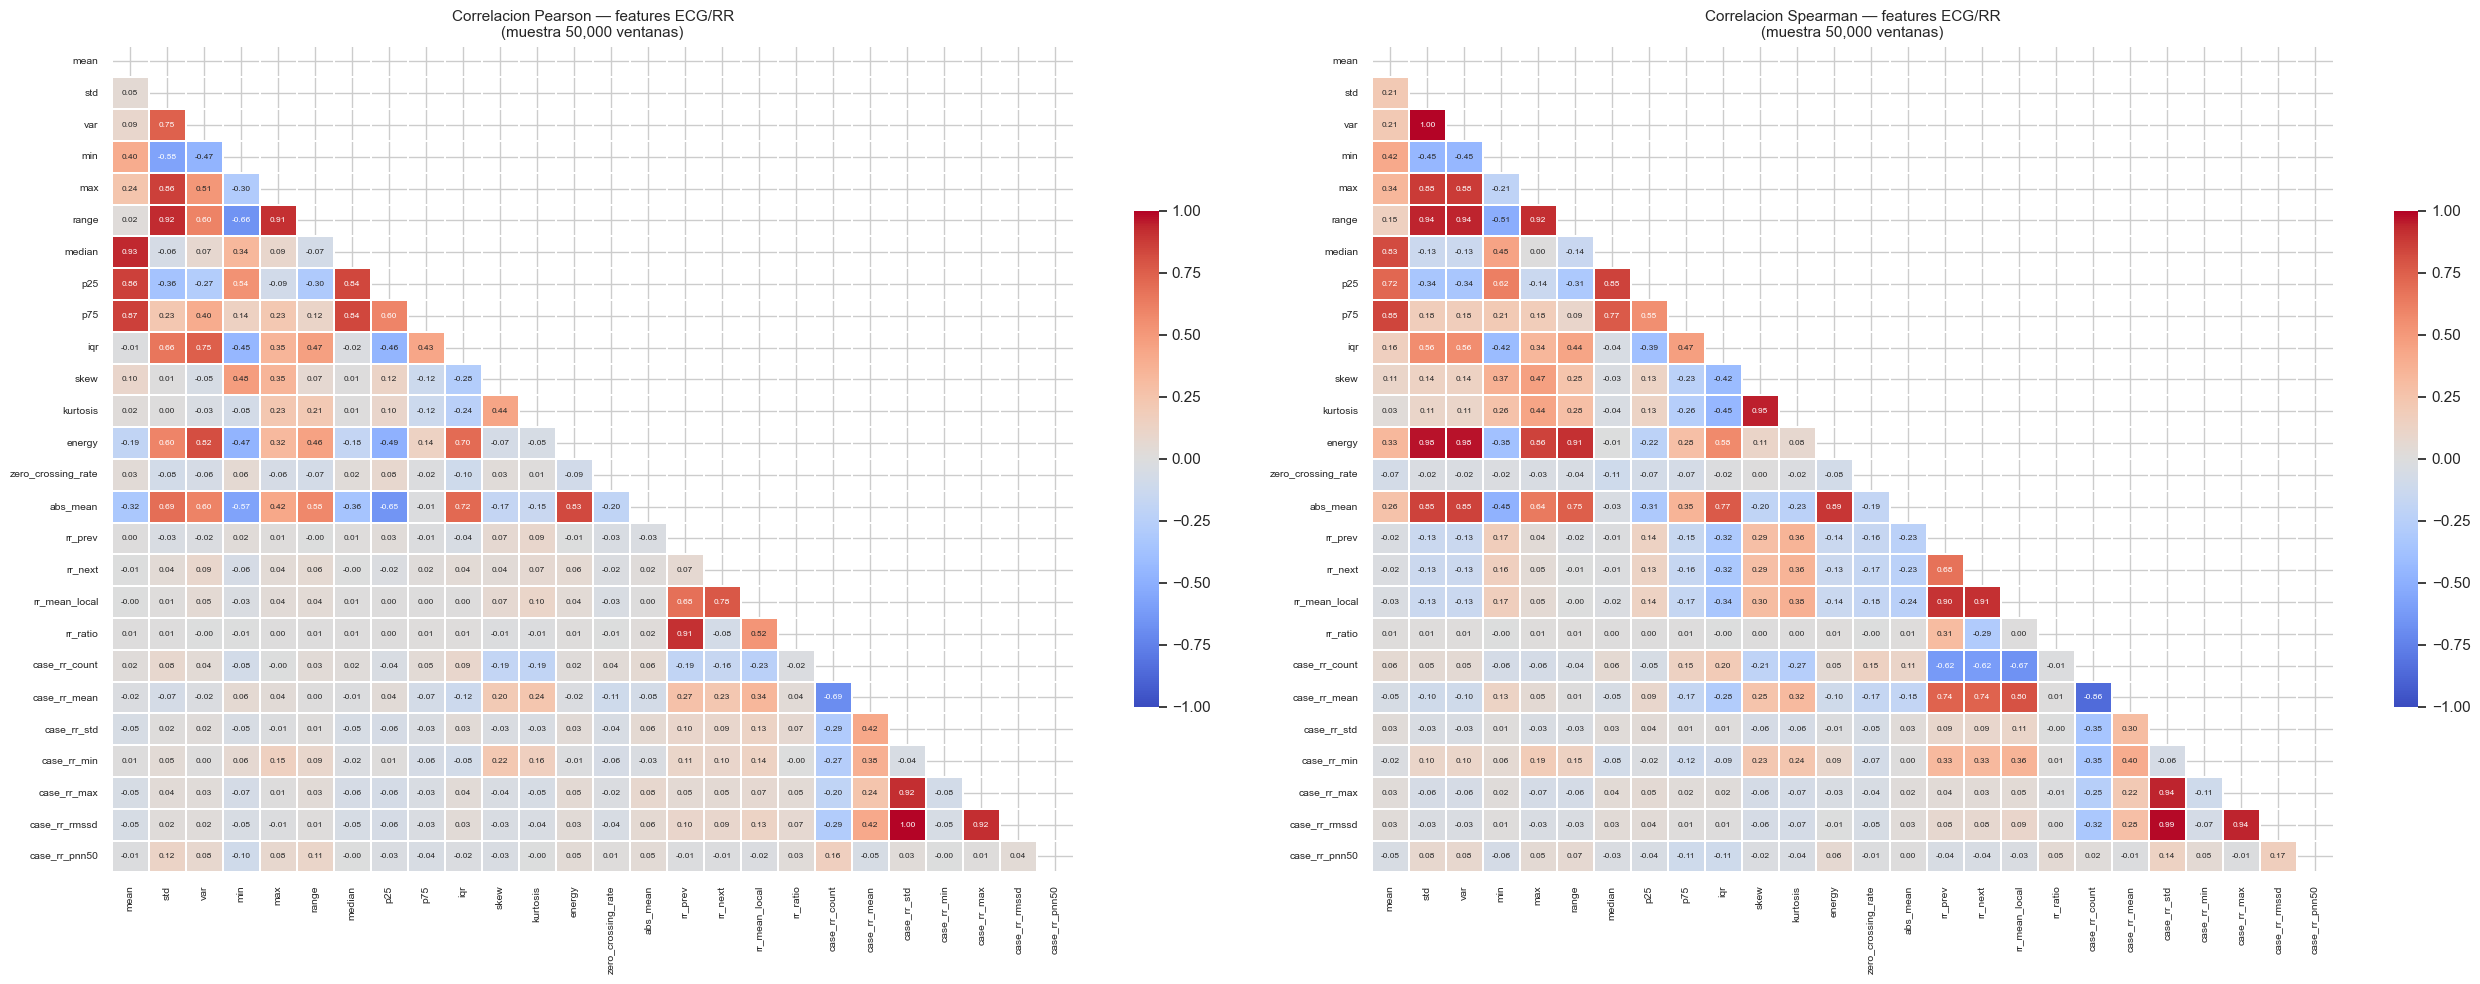

Heatmap guardado: ..\reports\figures\feature_correlation_heatmap.png
Muestra usada: 50,000 ventanas de 638,690 totales


In [20]:
# ================================================================
# TAREA B: Matriz de correlacion Pearson y Spearman — heatmap
# ================================================================
from pathlib import Path as _Path

# Muestra estratificada para acelerar el calculo
N_CORR = min(50_000, len(df))
rng_corr = np.random.default_rng(config.RANDOM_SEED)
sidx = rng_corr.choice(len(df), N_CORR, replace=False)
df_sample = df.iloc[sidx][feature_cols].copy()

corr_pearson  = df_sample.corr(method='pearson')
corr_spearman = df_sample.corr(method='spearman')

_Path('../reports/figures').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(26, 10))
for ax, corr, title in zip(
    axes,
    [corr_pearson, corr_spearman],
    ['Pearson', 'Spearman'],
):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
        center=0, vmin=-1, vmax=1, linewidths=0.3,
        annot_kws={'size': 6}, ax=ax,
        cbar_kws={'shrink': 0.6},
    )
    ax.set_title(
        f'Correlacion {title} — features ECG/RR\n(muestra {N_CORR:,} ventanas)',
        fontsize=11,
    )
    ax.tick_params(axis='both', labelsize=7.5)

plt.tight_layout()
_fig_path = _Path('../reports/figures/feature_correlation_heatmap.png')
plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Heatmap guardado: {_fig_path}')
print(f'Muestra usada: {N_CORR:,} ventanas de {len(df):,} totales')

In [21]:
# ================================================================
# TAREA B (cont.): Pares con correlacion alta + recomendaciones
# ================================================================

THRESHOLD_STRONG = 0.90  # redundancia fuerte
THRESHOLD_ALERT  = 0.85  # alerta

def _high_corr_pairs(corr_matrix, thr):
    cols = corr_matrix.columns.tolist()
    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= thr:
                rows.append({'feature_1': cols[i], 'feature_2': cols[j],
                             'pearson_r': round(r, 4), 'abs_r': round(abs(r), 4)})
    return pd.DataFrame(rows).sort_values('abs_r', ascending=False)

pairs_strong = _high_corr_pairs(corr_pearson, THRESHOLD_STRONG)
pairs_alert  = _high_corr_pairs(corr_pearson, THRESHOLD_ALERT)
pairs_only_alert = pairs_alert[pairs_alert['abs_r'] < THRESHOLD_STRONG]

print(f'Pares con |r| >= {THRESHOLD_STRONG} (redundancia fuerte — candidatos a eliminar):')
if pairs_strong.empty:
    print('  Ninguno encontrado con los datos actuales.')
else:
    print(pairs_strong.to_string(index=False))

print()
print(f'Pares con {THRESHOLD_ALERT} <= |r| < {THRESHOLD_STRONG} (alerta — revisar):')
if pairs_only_alert.empty:
    print('  Ninguno.')
else:
    print(pairs_only_alert.to_string(index=False))

# ---- Tabla de recomendaciones con razon clinica/matematica ----
_RECS = {
    frozenset({'std',  'var'}):             ('eliminar var',          'var = std^2 (identidad matematica, r=1.0)'),
    frozenset({'rr_mean_local', 'rr_prev'}): ('eliminar rr_mean_local', 'rr_mean_local = (rr_prev+rr_next)/2'),
    frozenset({'rr_mean_local', 'rr_next'}): ('eliminar rr_mean_local', 'rr_mean_local = (rr_prev+rr_next)/2'),
    frozenset({'min', 'range'}):             ('revisar range',          'range = max-min; derivado de min y max'),
    frozenset({'max', 'range'}):             ('revisar range',          'range = max-min; derivado de min y max'),
    frozenset({'energy', 'var'}):            ('revisar energy',         'energy ~ n*(var+mean^2)'),
    frozenset({'energy', 'std'}):            ('revisar energy',         'energy ~ n*(std^2+mean^2)'),
    frozenset({'mean', 'abs_mean'}):         ('revisar abs_mean',       'alta correlacion; abs_mean util si la senial es asimetrica'),
    frozenset({'mean', 'median'}):           ('conservar ambas',        'media vs mediana — la diferencia captura asimetria (skew)'),
    frozenset({'case_rr_min', 'case_rr_mean'}): ('revisar',             'correlacion moderada; case_rr_min puede aportarse con HRV extrema'),
    frozenset({'case_rr_max', 'case_rr_mean'}): ('revisar',             'idem que anterior'),
    frozenset({'case_rr_std', 'case_rr_rmssd'}): ('revisar case_rr_std', 'rmssd y std-RR miden variabilidad; rmssd es el estandar HRV'),
}

if not pairs_alert.empty:
    print()
    print('Tabla de recomendaciones:')
    rec_rows = []
    for _, row in pairs_alert.iterrows():
        key = frozenset({row['feature_1'], row['feature_2']})
        rec, razon = _RECS.get(key, ('revisar', 'correlacion elevada sin regla explicita'))
        rec_rows.append({'feature_1': row['feature_1'], 'feature_2': row['feature_2'],
                         'pearson_r': row['pearson_r'], 'recomendacion': rec, 'razon': razon})
    rec_df = pd.DataFrame(rec_rows)
    print(rec_df.to_string(index=False))
    print()
    rec_df.to_csv(config.PROCESSED_DIR / 'feature_correlation_recommendations.csv', index=False)
    print('Tabla guardada en data/processed/feature_correlation_recommendations.csv')

Pares con |r| >= 0.9 (redundancia fuerte — candidatos a eliminar):
  feature_1     feature_2  pearson_r  abs_r
case_rr_std case_rr_rmssd     0.9987 0.9987
       mean        median     0.9328 0.9328
        std         range     0.9242 0.9242
case_rr_max case_rr_rmssd     0.9188 0.9188
case_rr_std   case_rr_max     0.9180 0.9180
        max         range     0.9117 0.9117
    rr_prev      rr_ratio     0.9064 0.9064

Pares con 0.85 <= |r| < 0.9 (alerta — revisar):
feature_1 feature_2  pearson_r  abs_r
     mean       p75     0.8650 0.8650
     mean       p25     0.8634 0.8634
      std       max     0.8626 0.8626

Tabla de recomendaciones:
  feature_1     feature_2  pearson_r       recomendacion                                                       razon
case_rr_std case_rr_rmssd     0.9987 revisar case_rr_std rmssd y std-RR miden variabilidad; rmssd es el estandar HRV
       mean        median     0.9328     conservar ambas   media vs mediana — la diferencia captura asimetria (skew)
  

## 4c. Tarea C — Sets de features y comparación de modelos

Se definen dos conjuntos:
- **`features_all`**: todas las features numéricas disponibles.
- **`features_reduced`**: sin redundancias matemáticas evidentes.

El entrenamiento se repite con ambos sets para comparar métricas.
El dataset original **no se modifica**.

In [22]:
# ================================================================
# TAREA C: Definicion de sets de features y preparacion de X alternativo
# ================================================================

# --- Set completo ---
features_all = list(feature_cols)

# --- Set reducido: eliminar redundancias matematicas ciertas ---
# var        = std^2      (r=1.0 garantizado por definicion)
# rr_mean_local = media(rr_prev, rr_next)  (combinacion lineal exacta)
# Adicionalmente, si los datos muestran |r|>0.90 en pares adicionales,
# se elimina la feature con menor interpretabilidad clinica.
_REMOVE_FIXED = {'var', 'rr_mean_local'}  # redundancias garantizadas

# Agregar features con redundancia fuerte detectada en los datos
_REMOVE_DATA = set()
_PRIORITY = {
    # Si el par tiene |r|>0.90, eliminar la segunda de cada par
    frozenset({'std', 'var'}):              'var',
    frozenset({'rr_mean_local', 'rr_prev'}): 'rr_mean_local',
    frozenset({'rr_mean_local', 'rr_next'}): 'rr_mean_local',
    frozenset({'energy', 'var'}):           'energy',
    frozenset({'energy', 'std'}):           'energy',
    frozenset({'min',   'range'}):          'range',
    frozenset({'max',   'range'}):          'range',
    frozenset({'mean',  'abs_mean'}):       'abs_mean',
    frozenset({'case_rr_std', 'case_rr_rmssd'}): 'case_rr_std',
}
for _, row in pairs_strong.iterrows():
    key = frozenset({row['feature_1'], row['feature_2']})
    victim = _PRIORITY.get(key)
    if victim:
        _REMOVE_DATA.add(victim)

remove_set   = _REMOVE_FIXED | _REMOVE_DATA
features_reduced = [f for f in features_all if f not in remove_set]

# --- Arrays X para ambos sets ---
X_all     = df[features_all].to_numpy(dtype=float)
X_reduced = df[features_reduced].to_numpy(dtype=float)

print("=" * 66)
print("SETS DE FEATURES")
print("=" * 66)
print(f"features_all     ({len(features_all):2d} features): {features_all}")
print()
print(f"Eliminadas del set reducido ({len(remove_set)}): {sorted(remove_set)}")
print()
print(f"features_reduced ({len(features_reduced):2d} features): {features_reduced}")
print()
print("Impacto de multicolinealidad por modelo:")
print("  Logistic Regression : SENSIBLE — coeficientes inestables con features correlacionadas")
print("  SVM (lineal/RBF)    : SENSIBLE (lineal), moderado (RBF con gamma)")
print("  KNN                 : SENSIBLE — distancia euclidea amplificada por features redundantes")
print("  Random Forest       : ROBUSTO — seleccion aleatoria de features por split")
print("  XGBoost             : ROBUSTO — boosting con regularizacion")
print("  MLP                 : MODERADO — regularizacion L2 ayuda; mucho ruido puede perjudicar")
print()
print("Estrategia: entrenar con AMBOS sets y comparar metricas macro F1.")
print("  Si features_reduced da F1 similar o mejor -> preferir por parsimonia.")
print("  Si features_all da F1 notablemente mayor  -> conservar features extra.")
print("=" * 66)

SETS DE FEATURES
features_all     (26 features): ['mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']

Eliminadas del set reducido (4): ['case_rr_std', 'range', 'rr_mean_local', 'var']

features_reduced (22 features): ['mean', 'std', 'min', 'max', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']

Impacto de multicolinealidad por modelo:
  Logistic Regression : SENSIBLE — coeficientes inestables con features correlacionadas
  SVM (lineal/RBF)    : SENSIBLE (lineal), moderado (RBF con gamma)
  KNN                 : SENSIBLE — distancia euclidea amplificada por feature

### Comparación rápida: features_all vs features_reduced

Se entrena LogReg sobre un único split (train/test) con ambos sets.
El entrenamiento completo con todos los modelos continúa en las secciones 6-10
usando el set activo definido por `X`.

In [23]:
# Comparacion rapida de macro F1 con ambos sets (LogReg, un solo split)
from src.evaluation import compute_macro_metrics
from src.modeling import build_logreg_pipeline, make_group_split

compare_results = {}
for label, X_cmp in [('features_all', X_all), ('features_reduced', X_reduced)]:
    tr, te = make_group_split(X_cmp, y, groups, test_size=0.2,
                               random_state=config.RANDOM_SEED)
    pipe_cmp = build_logreg_pipeline(class_weight='balanced')
    pipe_cmp.fit(X_cmp[tr], y[tr])
    y_pred_cmp = pipe_cmp.predict(X_cmp[te])
    compare_results[label] = compute_macro_metrics(y[te], y_pred_cmp)
    compare_results[label]['n_features'] = X_cmp.shape[1]

cmp_df = pd.DataFrame(compare_results).T

print("Columnas disponibles en cmp_df:")
print(cmp_df.columns.tolist())

cols_to_show = [
    "n_features",
    "accuracy",
    "f1_macro",
    "precision_macro",
    "recall_macro",
]

cols_to_show = [c for c in cols_to_show if c in cmp_df.columns]

print("Comparacion LogReg — features_all vs features_reduced:")
print(cmp_df[cols_to_show].round(4))
print()

# Elegir X activo para el resto del notebook
# Cambiar a X_reduced si la diferencia de F1 es < 0.005 (parsimonia)
f1_all = compare_results['features_all'].get('f1_macro', 0)
f1_red = compare_results['features_reduced'].get('f1_macro', 0)
USE_REDUCED = (f1_all - f1_red) < 0.005

if USE_REDUCED:
    X = X_reduced
    active_features = features_reduced
    print(f"Usando features_reduced ({len(features_reduced)} features) — diferencia F1 < 0.005.")
else:
    X = X_all
    active_features = features_all
    print(f"Usando features_all ({len(features_all)} features) — features_reduced pierde >{(f1_all-f1_red):.4f} de F1.")

print(f"X activo: {X.shape} | NaN en X: {int(np.isnan(X).sum())}")

c:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Columnas disponibles en cmp_df:
['f1_macro', 'recall_macro', 'precision_macro', 'balanced_accuracy', 'n_features']
Comparacion LogReg — features_all vs features_reduced:
                  n_features  f1_macro  precision_macro  recall_macro
features_all            26.0    0.2724           0.2672        0.3917
features_reduced        22.0    0.2536           0.2652        0.3465

Usando features_all (26 features) — features_reduced pierde >0.0188 de F1.
X activo: (638690, 26) | NaN en X: 1920


c:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 5. Split por `case_id` y diagnóstico de soporte por split

Se hace un único split (`GroupShuffleSplit`, `test_size=0.2`). Antes de entrenar, se reporta cuántas muestras de cada clase quedaron en train y test.

In [24]:
train_idx, test_idx = make_group_split(X, y, groups, test_size=0.2, random_state=config.RANDOM_SEED)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Hard-check: ningún case_id puede aparecer en ambos lados.
assert set(groups_train).isdisjoint(set(groups_test)), "Fuga de grupo entre train y test."

print("Casos en train:", sorted(set(groups_train.tolist())))
print("Casos en test :", sorted(set(groups_test.tolist())))
print("Ventanas train:", X_train.shape[0], "| Ventanas test:", X_test.shape[0])

Casos en train: [13, 19, 42, 96, 98, 103, 110, 114, 158, 174, 178, 208, 230, 232, 253, 257, 285, 337, 345, 365, 371, 382, 387, 397, 447, 472, 484, 521, 539, 541, 554, 565, 569, 581, 584, 603, 634, 643, 657, 661, 672, 696, 708, 713, 746, 788, 816, 846, 853, 862, 864, 916, 939, 964, 965, 985, 1002, 1063, 1121, 1127, 1157, 1165, 1191, 1207, 1269, 1276, 1292, 1314, 1317, 1367, 1375, 1377, 1378, 1398, 1404, 1407, 1420, 1481, 1488, 1523, 1590, 1605, 1607, 1622, 1623, 1626, 1632, 1665, 1699, 1730, 1733, 1738, 1755, 1776, 1798, 1800, 1807, 1810, 1813, 1827, 1828, 1835, 1840, 1903, 1914, 1915, 1957, 1994, 1996, 2008, 2016, 2018, 2040, 2042, 2054, 2058, 2067, 2103, 2130, 2149, 2158, 2213, 2218, 2221, 2231, 2246, 2252, 2283, 2296, 2305, 2306, 2345, 2348, 2349, 2381, 2387, 2397, 2424, 2432, 2447, 2453, 2480, 2495, 2505, 2549, 2556, 2585, 2588, 2596, 2601, 2611, 2618, 2634, 2651, 2662, 2668, 2686, 2693, 2699, 2717, 2722, 2735, 2762, 2775, 2778, 2795, 2810, 2836, 2844, 2852, 2863, 2872, 2878, 2891, 

In [25]:
support_df = class_support_per_split(y_train, y_test)
support_df

,train,test,total
AFIB/AFL,121521,36952,158473
AVB,4193,0,4193
N,312021,79856,391877
Patterned Atrial Ectopy,16635,3311,19946
Patterned Ventricular Ectopy,19442,4460,23902
SND,16622,5602,22224
SVTA,2681,3715,6396
Unclassifiable,48,11,59
VT,1173,400,1573
WAP/MAT,9534,513,10047


In [26]:
missing = classes_missing_in_train(y_train, y_test)
if missing:
    print(
        "AVISO: estas clases aparecen en test pero NO en train.\n"
        "Por construcción su recall será 0 y arrastrarán f1_macro hacia abajo:\n",
        missing,
    )
else:
    print("Todas las clases de test están representadas en train.")

Todas las clases de test están representadas en train.


## 6. Definición del Pipeline

Pipeline scikit-learn: `SimpleImputer(strategy="median") → StandardScaler → Clasificador`. Todas las etapas viven dentro del mismo `Pipeline` para que `fit` se haga solo sobre train (sin fuga). El imputer permite que el pipeline tolere NaN en features sin necesidad de limpiar a mano.

Ambos clasificadores se configuran con `class_weight="balanced"` para penalizar más los errores en clases minoritarias.

In [27]:
pipelines = {
    "logreg": build_logreg_pipeline(class_weight="balanced"),
    "random_forest": build_rf_pipeline(class_weight="balanced"),
}
for name, pipe in pipelines.items():
    print(f"--- {name} ---")
    print(pipe)

--- logreg ---
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])
--- random_forest ---
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])


## 7. Entrenamiento, predicción y métricas macro

In [28]:
results = {}
for name, pipe in pipelines.items():
    logger.info("Entrenando %s...", name)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "metrics": compute_macro_metrics(y_test, y_pred),
    }

metrics_df = pd.DataFrame({name: info["metrics"] for name, info in results.items()}).T
metrics_df

2026-05-19 20:43:03 | nb05 | INFO | Entrenando logreg...
c:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
2026-05-19 20:43:53 | nb05 | INFO | Entrenando random_forest...


,f1_macro,recall_macro,precision_macro,balanced_accuracy
logreg,0.272418,0.391745,0.267185,0.435273
random_forest,0.250014,0.247089,0.488078,0.247089


## 8. Reporte por clase (con `support`)

La columna `support` indica cuántas muestras reales tiene cada clase en `y_test`. Si una clase tiene `support=0` o muy bajo, su F1 no es interpretable como métrica estable; conviene leerla junto con la matriz de confusión absoluta de la sección siguiente.

In [29]:
for name, info in results.items():
    print(f"=== {name} — reporte por clase ===")
    rep = per_class_report(y_test, info["y_pred"])
    print(rep.round(3).to_string())
    print()

=== logreg — reporte por clase ===
                              precision  recall  f1-score     support
AFIB/AFL                          0.865   0.747     0.801   36952.000
AVB                               0.000   0.000     0.000       0.000
N                                 0.976   0.535     0.691   79856.000
Patterned Atrial Ectopy           0.171   0.692     0.274    3311.000
Patterned Ventricular Ectopy      0.216   0.769     0.337    4460.000
SND                               0.160   0.374     0.224    5602.000
SVTA                              0.109   0.129     0.118    3715.000
Unclassifiable                    0.000   0.000     0.000      11.000
VT                                0.175   0.670     0.277     400.000
WAP/MAT                           0.000   0.002     0.001     513.000
accuracy                          0.585   0.585     0.585       0.585
macro avg                         0.267   0.392     0.272  134820.000
weighted avg                      0.837   0.585     0.6

## 9. Matriz de confusión en conteos absolutos + totales

Se reporta la matriz **sin normalizar** porque con clases muy desbalanceadas los porcentajes pueden ser engañosos.

- Filas = clases reales (`y_true`).
- Columnas = clases predichas (`y_pred`).
- Columna extra `support_true`: cuántas muestras de cada clase real había en test.
- Fila extra `predicted_total`: cuántas predicciones cayeron en cada clase.

=== logreg — matriz de confusión absoluta ===
                              AFIB/AFL   AVB      N  Patterned Atrial Ectopy  Patterned Ventricular Ectopy    SND  SVTA  Unclassifiable    VT  WAP/MAT  support_true
AFIB/AFL                         27588    36    273                     2055                          5111     33   645               1    39     1171         36952
AVB                                  0     0      0                        0                             0      0     0               0     0        0             0
N                                 1089  4452  42746                     7610                          6953  10100  2975            2518  1078      335         79856
Patterned Atrial Ectopy            271     2     95                     2292                           238    109   110             104    41       49          3311
Patterned Ventricular Ectopy         4    15    187                      347                          3429    366    29          

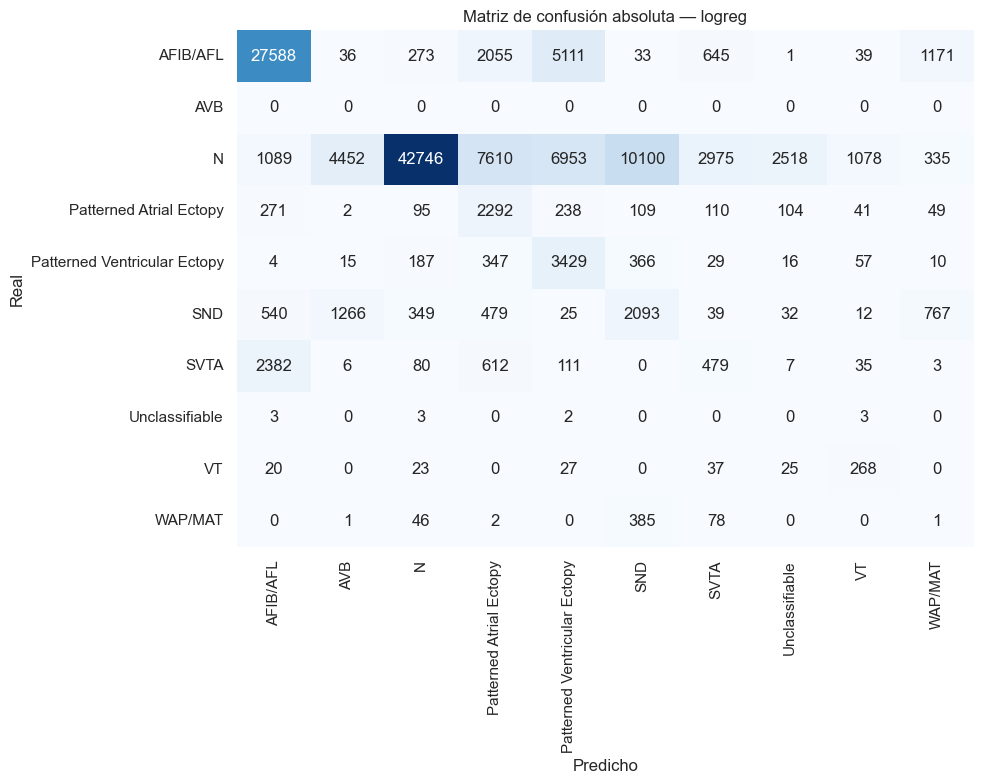


=== random_forest — matriz de confusión absoluta ===
                              AFIB/AFL      N  Patterned Atrial Ectopy  Patterned Ventricular Ectopy  SND  SVTA  Unclassifiable   VT  WAP/MAT  support_true
AFIB/AFL                         34656   2251                        0                             9    0     0               0   36        0         36952
N                                  619  79158                        0                            63    1     1               0   14        0         79856
Patterned Atrial Ectopy           1861   1450                        0                             0    0     0               0    0        0          3311
Patterned Ventricular Ectopy      1430   2929                        0                           100    1     0               0    0        0          4460
SND                                699   4899                        0                             0    4     0               0    0        0          5602
SVTA      

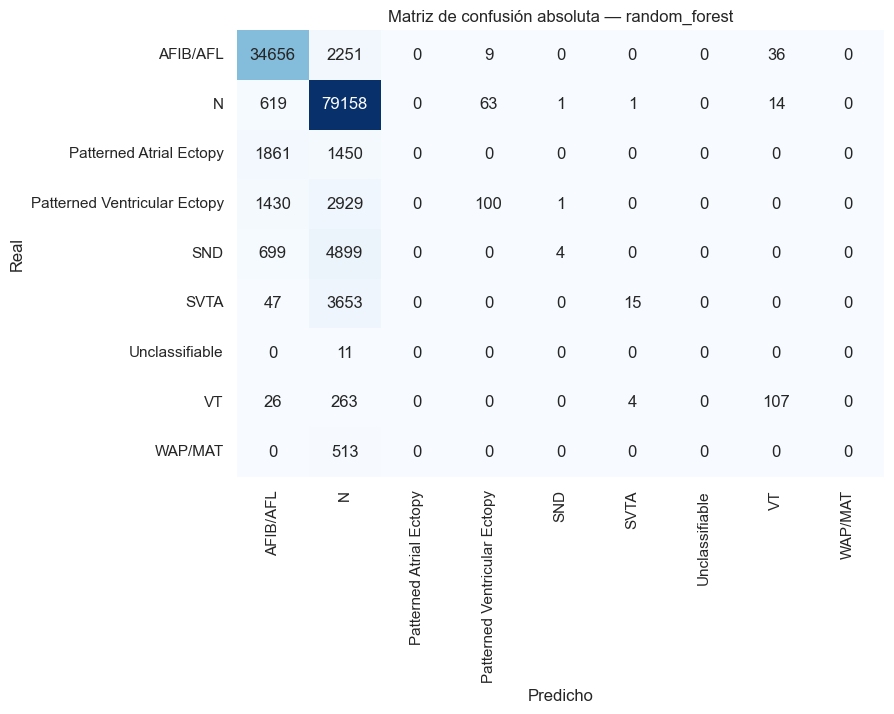

In [30]:
for name, info in results.items():
    cm_df = confusion_matrix_with_totals(y_test, info["y_pred"])
    print(f"=== {name} — matriz de confusión absoluta ===")
    print(cm_df.to_string())

    # Heatmap solo de la submatriz (sin la fila/col de totales).
    inner = cm_df.iloc[:-1, :-1]
    fig, ax = plt.subplots(figsize=(1.0 + 0.9 * inner.shape[1], 1.0 + 0.7 * inner.shape[0]))
    sns.heatmap(
        inner,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"Matriz de confusión absoluta — {name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.show()
    print()

## 10. Validación cruzada por grupos (`GroupKFold`)

`safe_n_splits` recorta automáticamente el número de folds al número de `case_id` únicos cuando son menos de los pedidos (`GroupKFold` exige `n_splits <= n_groups`).

Se reporta una métrica por fold y los grupos que cayeron en test de cada fold.

In [31]:
n_splits_eff = safe_n_splits(config.DEFAULT_N_SPLITS, groups)
print(f"n_splits efectivo (recortado por # de grupos): {n_splits_eff}")

fold_metrics = []
for i, (tr, te) in enumerate(make_group_kfold(X, y, groups, n_splits=n_splits_eff)):
    pipe = build_logreg_pipeline(class_weight="balanced")
    pipe.fit(X[tr], y[tr])
    y_pred = pipe.predict(X[te])
    m = compute_macro_metrics(y[te], y_pred)
    m["fold"] = i
    m["test_groups"] = sorted(set(groups[te].tolist()))
    m["n_test"] = int(len(te))
    fold_metrics.append(m)

cv_df = pd.DataFrame(fold_metrics).set_index("fold")
cv_df

n_splits efectivo (recortado por # de grupos): 5


c:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,f1_macro,recall_macro,precision_macro,balanced_accuracy,test_groups,n_test
fold,,,,,,
0,0.244247,0.414528,0.257569,0.414528,"[12, 347, 382, 565, 569, 672, 708, 758, 788, 9...",127813
1,0.233029,0.429954,0.251458,0.429954,"[42, 96, 285, 447, 539, 541, 657, 816, 985, 10...",127645
2,0.237311,0.335215,0.255362,0.372461,"[110, 146, 178, 230, 251, 257, 371, 397, 521, ...",127842
3,0.265741,0.387033,0.272771,0.387033,"[13, 103, 114, 158, 166, 208, 244, 345, 387, 4...",127705
4,0.306643,0.550367,0.298373,0.550367,"[19, 98, 174, 212, 232, 253, 337, 365, 388, 45...",127685


In [32]:
numeric_cols = [c for c in cv_df.columns if pd.api.types.is_numeric_dtype(cv_df[c])]
cv_df[numeric_cols].agg(["mean", "std", "min", "max"]).round(3)

,f1_macro,recall_macro,precision_macro,balanced_accuracy,n_test
mean,0.257,0.423,0.267,0.431,127738.000
std,0.030,0.080,0.019,0.070,85.129
min,0.233,0.335,0.251,0.372,127645.000
max,0.307,0.550,0.298,0.550,127842.000


## 11. Lectura del baseline y próximos pasos

Cómo interpretar lo que ves arriba antes de pasar a búsqueda de hiperparámetros:

1. Si en la sección 3 alguna clase aparece en **≤ 1 case_id**, sus métricas en cualquier fold donde ese caso quede en test no serán informativas. Más casos en `03` mitigan esto.
2. Si en la sección 5 hay clases listadas como *missing in train*, su recall será 0 por construcción y `f1_macro` no es comparable contra runs sin ese problema.
3. La matriz de confusión absoluta de la sección 9 muestra dónde están concentrados los errores. Mirar primero las clases con mayor `support_true` (los errores ahí mueven la métrica) y luego las minoritarias.
4. La tabla de la sección 10 expone la variabilidad entre folds. Una media alta con desviación enorme suele indicar que el resultado depende del fold concreto, no del modelo.

Antes de iterar en modelado:

- Asegurar que `03_ecg_loading_and_visualization.ipynb` haya descargado suficientes `case_id`.
- Re-ejecutar `04_windowing_and_feature_engineering.ipynb` para regenerar `features_baseline.parquet` con todos los casos.
- Volver a correr este notebook entero y comparar la sección 10 contra el run anterior.